# Imports

In [1]:
import pandas as pd

# Charger, observer et comprendre le dataset

In [2]:
df = pd.read_csv('../../../../Data/tp5/credit.csv',sep=',',index_col='Loan_ID')

df.head(10)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
Loan_ID,,,,,,,,,,,,
LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y
LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y
LP001014,Male,Yes,3+,Graduate,No,3036,2504.0,158.0,360.0,0.0,Semiurban,N
LP001018,Male,Yes,2,Graduate,No,4006,1526.0,168.0,360.0,1.0,Urban,Y


### Describe les données

In [3]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


# Afficher les données manquantes

In [4]:
df.isnull().sum()

Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [5]:
df[df.isnull().any(axis=1)]

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
Loan_ID,,,,,,,,,,,,
LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
LP001027,Male,Yes,2,Graduate,NaN,2500,1840.0,109.0,360.0,1.0,Urban,Y
LP001034,Male,No,1,Not Graduate,No,3596,0.0,100.0,240.0,NaN,Urban,Y
LP001041,Male,Yes,0,Graduate,NaN,2600,3500.0,115.0,NaN,1.0,Urban,Y
LP001050,NaN,Yes,2,Not Graduate,No,3365,1917.0,112.0,360.0,0.0,Rural,N
...,...,...,...,...,...,...,...,...,...,...,...,...
LP002933,NaN,No,3+,Graduate,Yes,9357,0.0,292.0,360.0,1.0,Semiurban,Y
LP002943,Male,No,NaN,Graduate,No,2987,0.0,88.0,360.0,0.0,Semiurban,N
LP002949,Female,No,3+,Graduate,NaN,416,41667.0,350.0,180.0,NaN,Urban,N


# Transformer les données catégorielles en données numériques

In [6]:
from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder()

cat_cols = ['Gender','Married','Dependents','Education','Self_Employed','Property_Area','Loan_Status']

df[cat_cols] = encoder.fit_transform(df[cat_cols])

df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
Loan_ID,,,,,,,,,,,,
LP001002,1.0,0.0,0.0,0.0,0.0,5849,0.0,NaN,360.0,1.0,2.0,1.0
LP001003,1.0,1.0,1.0,0.0,0.0,4583,1508.0,128.0,360.0,1.0,0.0,0.0
LP001005,1.0,1.0,0.0,0.0,1.0,3000,0.0,66.0,360.0,1.0,2.0,1.0
LP001006,1.0,1.0,0.0,1.0,0.0,2583,2358.0,120.0,360.0,1.0,2.0,1.0
LP001008,1.0,0.0,0.0,0.0,0.0,6000,0.0,141.0,360.0,1.0,2.0,1.0


# Traiter les données manquantes
Pour traiter les données manquantes, regarder `SimpleImputer` ou `KNNImputer`

In [7]:
from sklearn.impute import SimpleImputer

num_imputer = SimpleImputer(strategy='median')
df[df.columns] = num_imputer.fit_transform(df[df.columns])

df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
Loan_ID,,,,,,,,,,,,
LP001002,1.0,0.0,0.0,0.0,0.0,5849.0,0.0,128.0,360.0,1.0,2.0,1.0
LP001003,1.0,1.0,1.0,0.0,0.0,4583.0,1508.0,128.0,360.0,1.0,0.0,0.0
LP001005,1.0,1.0,0.0,0.0,1.0,3000.0,0.0,66.0,360.0,1.0,2.0,1.0
LP001006,1.0,1.0,0.0,1.0,0.0,2583.0,2358.0,120.0,360.0,1.0,2.0,1.0
LP001008,1.0,0.0,0.0,0.0,0.0,6000.0,0.0,141.0,360.0,1.0,2.0,1.0


# Standardiser les données

In [8]:
from sklearn.preprocessing import StandardScaler

scaler_cols = ['ApplicantIncome','CoapplicantIncome','LoanAmount','Loan_Amount_Term']

df[scaler_cols] = StandardScaler().fit_transform(df[scaler_cols])

df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
Loan_ID,,,,,,,,,,,,
LP001002,1.0,0.0,0.0,0.0,0.0,0.072991,-0.554487,-0.211241,0.273231,1.0,2.0,1.0
LP001003,1.0,1.0,1.0,0.0,0.0,-0.134412,-0.038732,-0.211241,0.273231,1.0,0.0,0.0
LP001005,1.0,1.0,0.0,0.0,1.0,-0.393747,-0.554487,-0.948996,0.273231,1.0,2.0,1.0
LP001006,1.0,1.0,0.0,1.0,0.0,-0.462062,0.251980,-0.306435,0.273231,1.0,2.0,1.0
LP001008,1.0,0.0,0.0,0.0,0.0,0.097728,-0.554487,-0.056551,0.273231,1.0,2.0,1.0


# Séparer le dataset en train et test

In [9]:
X = df.drop(columns=['Loan_Status'])
y = df['Loan_Status']

print(X.shape)
print(y.shape)

X.head(2)

(614, 11)
(614,)


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
Loan_ID,,,,,,,,,,,
LP001002,1.0,0.0,0.0,0.0,0.0,0.072991,-0.554487,-0.211241,0.273231,1.0,2.0
LP001003,1.0,1.0,1.0,0.0,0.0,-0.134412,-0.038732,-0.211241,0.273231,1.0,0.0


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(491, 11)
(123, 11)
(491,)
(123,)


# Régression logistique
Entrainer une régression logistique avec les hyper-paramètres par défaut

In [11]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression()

log_reg.fit(X_train, y_train)

print("Score sur le Train :", log_reg.score(X_train,y_train))
print("Score sur le Test :", log_reg.score(X_test, y_test))

Score sur le Train : 0.8167006109979633
Score sur le Test : 0.7967479674796748


# KNN
Entrainer un KNN avec les hyper-paramètres par défaut. Puis, 
avec `GridSearchCV` ou `RandomizedSearchCV`, optimiser les hyper-paramètres. Utiliser une validation croisée de 5 splits. Vous explorerez les paramètres suivants:
- k : 3, 5, 7, 9, 11,
- poids : uniform, distance,
- distances : euclidean, manhattan, minkowski

In [12]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()

knn.fit(X_train, y_train)

print("Score sur le Train :", knn.score(X_train, y_train))
print("Score sur le Test :", knn.score(X_test, y_test))

Score sur le Train : 0.8228105906313645
Score sur le Test : 0.7154471544715447


In [13]:
from sklearn.model_selection import GridSearchCV

# 1. 定义你要探索的参数“网格” (字典格式，键的名字必须是模型参数的确切名称)
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

# 2. 初始化重新配置的基础模型
knn = KNeighborsClassifier()

# 3. 配置 GridSearchCV (网格搜索)
# cv=5 就是题目要求的 validation croisée de 5 splits
grid_search_knn = GridSearchCV(estimator=knn, param_grid=param_grid, cv=5, n_jobs=-1, verbose=1)

# 4. 启动搜索大战！让机器拿着所有组合在训练集上大练兵
# (由于要尝试 5 * 2 * 3 = 30 种组合，且每种验证 5 次，所以其实会在后台训练 150 个模型！)
print("\nRecherche des meilleurs hyper-paramètres en cours...")
grid_search_knn.fit(X_train, y_train)

# 5. 等待搜索完毕，打印老师最想看到的终极结果：
print("Meilleurs hyper-paramètres trouvés : ", grid_search_knn.best_params_)
print("Meilleur score en validation croisée : ", grid_search_knn.best_score_)

# 6. 直接使用这个“找到的最好模型”在测试集上看看实力
best_knn_model = grid_search_knn.best_estimator_
print("\n--- Meilleur Modèle KNN ---")
print("Score Train :", best_knn_model.score(X_train, y_train))
print("Score Test  :", best_knn_model.score(X_test, y_test))



Recherche des meilleurs hyper-paramètres en cours...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Meilleurs hyper-paramètres trouvés :  {'metric': 'manhattan', 'n_neighbors': 7, 'weights': 'distance'}
Meilleur score en validation croisée :  0.7759018759018759

--- Meilleur Modèle KNN ---
Score Train : 1.0
Score Test  : 0.7479674796747967


# SVM
Entrainer un SVM avec les hyper-paramètres par défaut
Avec `GridSearchCV` ou `RandomizedSearchCV`, optimiser les hyper-paramètres. Utiliser une validation croisée de 5 splits. Vous explorerez les paramètres suivants:
- C : 0.01, 0.1, 1, 10, 100,
- noyau : linear, poly, rbf, sigmoid,
- gamma : scale, auto, 0.001, 0.01, 0.1, 1,
- degrée du polynome : 2, 3, 4, 5

In [14]:
from sklearn.svm import SVC

svc = SVC()

svc.fit(X_train,y_train)

print(svc.score(X_train,y_train))
print(svc.score(X_test,y_test))

0.8309572301425662
0.7886178861788617


In [15]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'C':[0.01, 0.1, 1, 10, 100],
    'kernel':['linear', 'poly', 'rbf', 'sigmoid'],
    'gamma':['scale','auto',0.001,0.01,0.1,1],
    'degree':[2,3,4,5]
}

svc_grid = RandomizedSearchCV(SVC(),param_distributions=param_grid,cv=5, n_jobs=-1,n_iter=10, random_state=1)

svc_grid.fit(X_train,y_train)

print(svc_grid.best_params_)
print(svc_grid.best_score_)

best_svc_grid = svc_grid.best_estimator_
print(best_svc_grid.score(X_train,y_train))
print(best_svc_grid.score(X_test,y_test))


{'kernel': 'poly', 'gamma': 'auto', 'degree': 2, 'C': 10}
0.8146567717996289
0.8309572301425662
0.7723577235772358


# DecisionTree
Entrainer un arbre de décision avec les hyper-paramètres par défaut
Avec `GridSearchCV` ou `RandomizedSearchCV`, optimiser les hyper-paramètres. Utiliser une validation croisée de 5 splits. Vous explorerez les hyper-paramètres suivants:
- critère : gini, entropy,
- profondeur maximale : None, 10, 20, 30, 40, 50,
- nombre minimum d'exemples par split : 2, 5, 10, 20,
- nombre minimum d'exemples par feuille : 1, 2, 4, 6,
- nombre de features maximum : None, sqrt, log2

In [16]:
from sklearn.tree import DecisionTreeClassifier

dtc = DecisionTreeClassifier(random_state=1)

dtc.fit(X_train,y_train)

print(dtc.score(X_train,y_train))
print(dtc.score(X_test,y_test))

1.0
0.7235772357723578


In [17]:
from sklearn.model_selection import RandomizedSearchCV

param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 6],
    'max_features': [None, 'sqrt', 'log2']
}

dtc_RSCV = RandomizedSearchCV(DecisionTreeClassifier(random_state=1), param_distributions=param_grid_dt,cv=5,n_jobs=10,n_iter=10,random_state=1)

dtc_RSCV.fit(X_train,y_train)

print(dtc_RSCV.best_params_)
print(dtc_RSCV.best_score_)

best_dtc_RSCV = dtc_RSCV.best_estimator_
print(best_dtc_RSCV.score(X_train,y_train))
print(best_dtc_RSCV.score(X_test,y_test))

{'min_samples_split': 20, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 50, 'criterion': 'gini'}
0.7698824984539271
0.8207739307535642
0.8048780487804879


# RandomForest
Entrainer une forêt aléatoire avec les paramètres par défaut
Avec `GridSearchCV` ou `RandomizedSearchCV`, optimiser les hyper-paramètres. Utiliser une validation croisée de 5 splits. Vous explorerez les hyper-paramètres suivants:
- nombre d'arbres : 50, 100, 200, 300,
- critère : gini, entropy,
- profondeur maximale : None, 10, 20, 30, 40, 50,
- nombre minimum d'exemples par split : 2, 5, 10, 20,
- nombre minimum d'exemples par feuille : 1, 2, 4, 6,
- nombre de features maximum : None, sqrt, log2,
- remise des exemples : vrai, faux

In [18]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier()

rfc.fit(X_train, y_train)

print(rfc.score(X_train, y_train))
print(rfc.score(X_test, y_test))

1.0
0.7804878048780488


In [24]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [50, 100, 200, 300],          # 树的数量
    'criterion': ['gini', 'entropy'],             # 准则
    'max_depth': [None, 10, 20, 30, 40, 50],      # 最大深度 
    'min_samples_split': [2, 5, 10, 20],          # 分裂内部节点所需的最少样本数
    'min_samples_leaf': [1, 2, 4, 6],             # 每个叶子节点所需的最少样本数
    'max_features': [None, 'sqrt', 'log2'],       # 最大特征数 (旧版本sklearn中可能是'auto'，但新版已统一为'sqrt')
    'bootstrap': [True, False]                    # 是否进行有放回抽样(remise des exemples)
}


rfc_RSCV = RandomizedSearchCV(RandomForestClassifier(), param_distributions=param_grid, n_iter=10, cv=5, random_state=10, verbose=1)

rfc_RSCV.fit(X_train,y_train)

print(rfc_RSCV.best_params_)
print(rfc_RSCV.best_score_)

best_rfc_RSCV = rfc_RSCV.best_estimator_
print(best_rfc_RSCV.score(X_train,y_train))
print(best_rfc_RSCV.score(X_test,y_test))

Fitting 5 folds for each of 10 candidates, totalling 50 fits
{'n_estimators': 100, 'min_samples_split': 20, 'min_samples_leaf': 2, 'max_features': None, 'max_depth': 40, 'criterion': 'entropy', 'bootstrap': True}
0.8207998350855494
0.8635437881873728
0.8048780487804879


# Rapporter et analyser les résultats obtenir. Choisir le meilleur modèle

✅ Logistic Regression       calculé! Train: 0.8167 | Test: 0.7967
✅ KNN (Tuned)               calculé! Train: 1.0000 | Test: 0.7480
✅ SVM (Tuned)               calculé! Train: 0.8310 | Test: 0.7724
✅ Decision Tree (Tuned)     calculé! Train: 0.8208 | Test: 0.8049
✅ Random Forest (Tuned)     calculé! Train: 0.8635 | Test: 0.8049
--------------------------------------------------


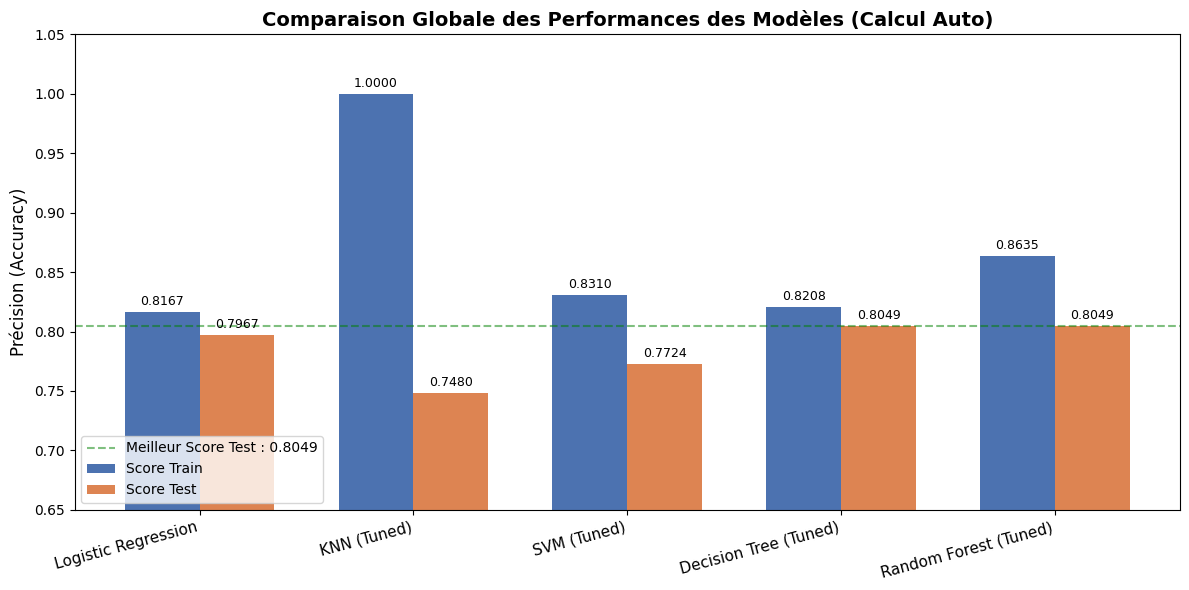

In [26]:
import matplotlib.pyplot as plt
import numpy as np
# ==========================================
# 1. 动态检索内存中所有的“最佳模型”进行装载
# （前提：前面的单元格都必须运行过，变量保存在内存中）
# ==========================================
# 把你的模型变量作为对象直接放入字典 (注意 log_reg 是我们前面建的逻辑回归模型)
models_dict = {
    'Logistic Regression': log_reg,
    'KNN (Tuned)': best_knn_model,
    'SVM (Tuned)': best_svc_grid,
    'Decision Tree (Tuned)': best_dtc_RSCV,
    'Random Forest (Tuned)': best_rfc_RSCV
}
models = list(models_dict.keys())
train_scores = []
test_scores = []
# 2. 自动化循环：利用模型的 .score() 方法实时读取最新得分
for name, model in models_dict.items():
    # 自动获取模型对 Train 和 Test 的预测打分
    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)
    
    # 存入列表
    train_scores.append(train_score)
    test_scores.append(test_score)
    
    print(f"✅ {name:25s} calculé! Train: {train_score:.4f} | Test: {test_score:.4f}")
print("-" * 50)
# ==========================================
# 3. 绘制对比柱状图 (Bar Chart)
# ==========================================
x = np.arange(len(models))  
width = 0.35  
fig, ax = plt.subplots(figsize=(12, 6))
# 画出柱子
rects1 = ax.bar(x - width/2, train_scores, width, label='Score Train', color='#4C72B0')
rects2 = ax.bar(x + width/2, test_scores, width, label='Score Test', color='#DD8452')
# 标签、标题和微调
ax.set_ylabel('Précision (Accuracy)', fontsize=12)
ax.set_title('Comparaison Globale des Performances des Modèles (Calcul Auto)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15, ha="right", fontsize=11)
ax.legend(loc='lower left')
# 限制 y 轴范围，让对比差异更加明显
ax.set_ylim(0.65, 1.05)
# 动态获取各个柱子的高度，并将数字标在柱头上
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.4f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)
autolabel(rects1)
autolabel(rects2)
# 动态画出目前最佳 test 分数的水平辅助线
best_test_score = max(test_scores)
ax.axhline(best_test_score, color='green', linestyle='--', alpha=0.5, label=f'Meilleur Score Test : {best_test_score:.4f}')
ax.legend(loc='lower left')
plt.tight_layout()
plt.show()

# Analyser le meilleur modèle
En utilisant `classification_report`, afficher différentes métriques en train et en test du modèle choisit. Afficher la matrice de confusion en train et en test de ce même modèle. Qu'en concluez-vous sur la qualité de ce modèle?

================= RESULTATS EN TRAIN =================
              precision    recall  f1-score   support

         0.0       0.84      0.54      0.66       156
         1.0       0.82      0.95      0.88       335

    accuracy                           0.82       491
   macro avg       0.83      0.75      0.77       491
weighted avg       0.82      0.82      0.81       491


================= RESULTATS EN TEST  =================
              precision    recall  f1-score   support

         0.0       0.93      0.36      0.52        36
         1.0       0.79      0.99      0.88        87

    accuracy                           0.80       123
   macro avg       0.86      0.67      0.70       123
weighted avg       0.83      0.80      0.77       123



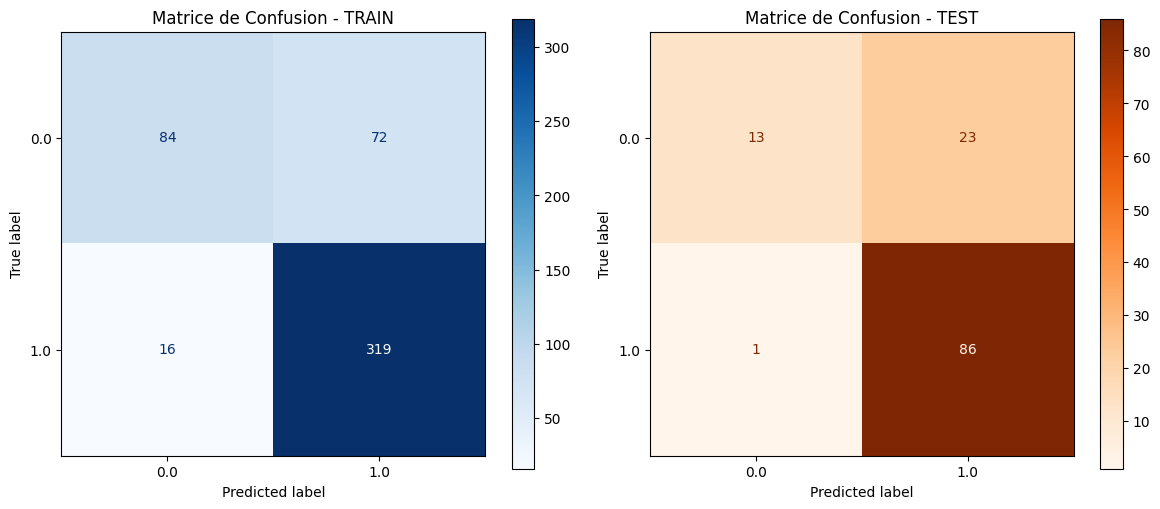

In [25]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# 我们选择在 Test 上表现最好的 Decision Tree 作为最佳模型
# 在你的代码中，它被保存在了 best_dtc_RSCV 中
meilleur_modele = best_dtc_RSCV

y_train_pred = meilleur_modele.predict(X_train)
y_test_pred = meilleur_modele.predict(X_test)

print("================= RESULTATS EN TRAIN =================")
print(classification_report(y_train, y_train_pred))

print("\n================= RESULTATS EN TEST  =================")
print(classification_report(y_test, y_test_pred))

# 绘制混淆矩阵
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_train = confusion_matrix(y_train, y_train_pred)
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=meilleur_modele.classes_)
disp_train.plot(cmap='Blues', ax=axes[0])
axes[0].set_title('Matrice de Confusion - TRAIN')

cm_test = confusion_matrix(y_test, y_test_pred)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=meilleur_modele.classes_)
disp_test.plot(cmap='Oranges', ax=axes[1])
axes[1].set_title('Matrice de Confusion - TEST')

plt.tight_layout()
plt.show()


# A faire à la maison : Développer un notebook similaire pour une tâche de régression